## EDA ---> Exploritory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/process_data/itsm_clean.csv')
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,KM0000553,closed,26.0,2012-02-05 13:32:00,2013-11-04 13:50:00,2013-11-04 13:51:00,15312.316667,Other,1.0,SD0000007
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,KM0000611,closed,33.0,2012-03-12 15:44:00,2013-12-02 12:36:00,2013-12-02 12:36:00,15116.866667,Software,1.0,SD0000011
2,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,KM0000611,closed,13.0,2012-07-17 11:49:00,2013-11-14 09:31:00,2013-11-14 09:31:00,11637.700000,Operator error,1.0,SD0000025
3,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,KM0000611,closed,2.0,2012-08-10 11:01:00,2013-11-08 13:55:00,2013-11-08 13:55:00,10922.900000,Other,1.0,SD0000029
4,WBA000124,application,Web Based Application,WBS000088,IM0000013,Closed,4,4,4.0,0.006676,...,KM0000611,closed,4.0,2012-08-10 11:27:00,2013-11-08 13:54:00,2013-11-08 13:54:00,10922.450000,Other,1.0,SD0000031


In [3]:
df.dtypes

CI_Name                           str
CI_Cat                            str
CI_Subcat                         str
WBS                               str
Incident_ID                       str
Status                            str
Impact                          int64
Urgency                         int64
Priority                      float64
number_cnt                    float64
Category                          str
KB_number                         str
Alert_Status                      str
No_of_Reassignments           float64
Open_Time                         str
Resolved_Time                     str
Close_Time                        str
Handle_Time_hrs               float64
Closure_Code                      str
No_of_Related_Interactions    float64
Related_Interaction               str
dtype: object

In [4]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Resolved_Time',
       'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction'],
      dtype='str')

In [5]:
columns_num = df.select_dtypes(include="number")
columns_cat_sort = ['Status', 'Category']

## Univariate Analysis (Distribution of Variables)

## Numerical column

In [6]:
columns_num.shape

(45117, 7)

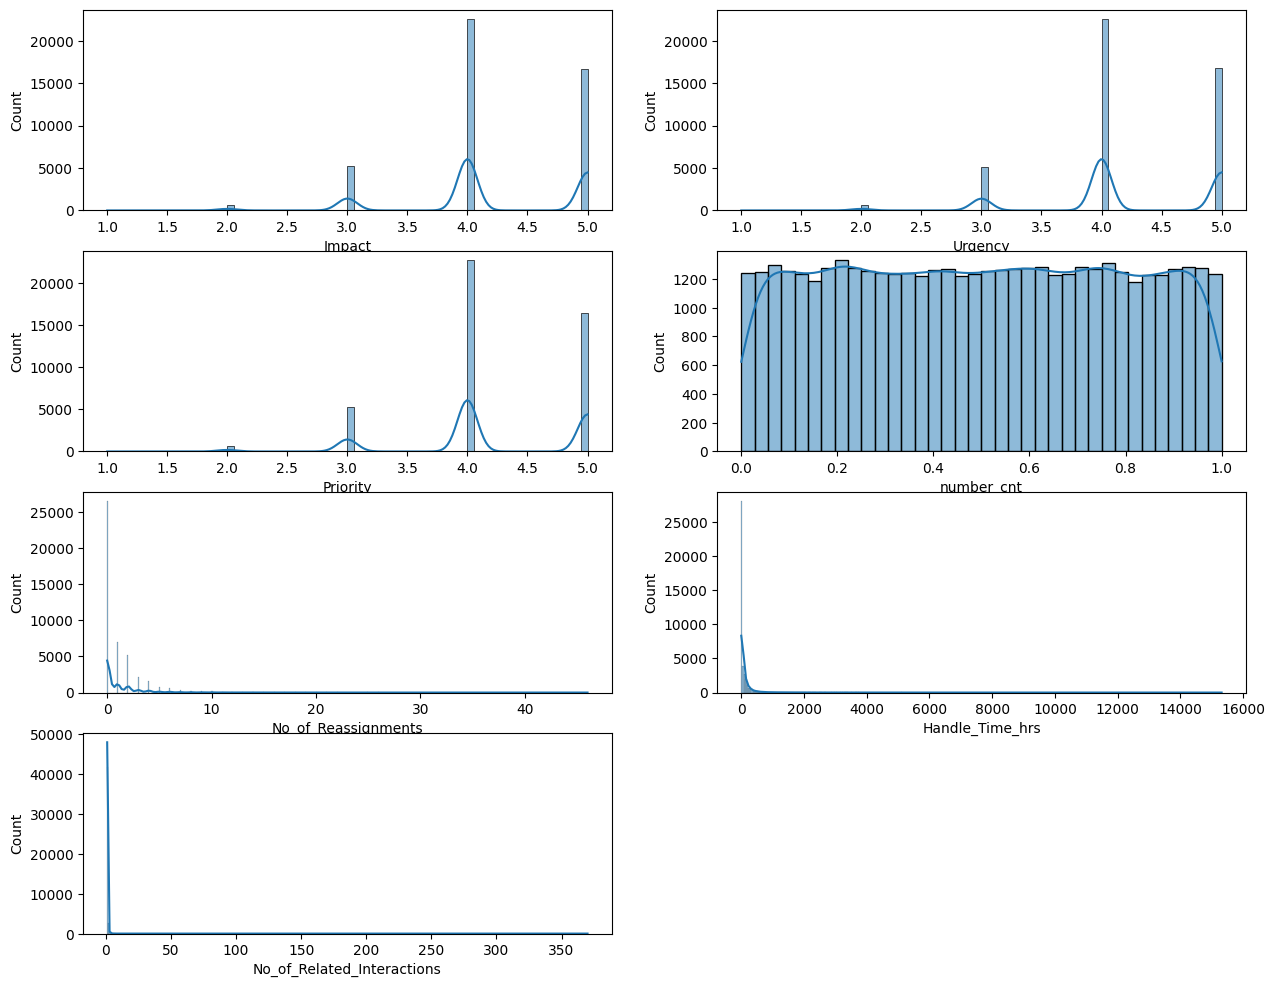

In [7]:
plt.figure(figsize=(15,12))

for i , col in enumerate(columns_num):
    plt.subplot(4,2,i+1)
    sns.histplot(columns_num[col],kde=True)

plt.show()

## Catagorical Columns

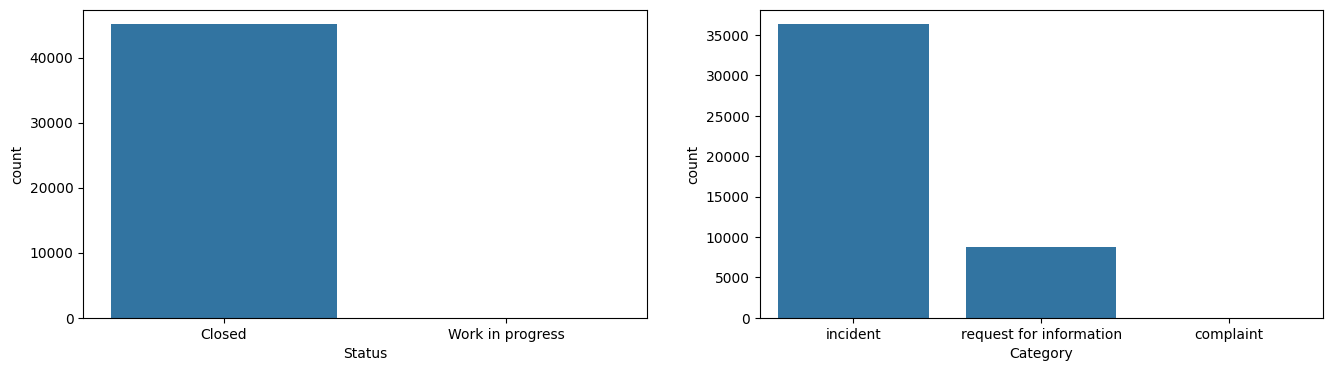

In [8]:
plt.figure(figsize=(16,4))

for i,col in enumerate(columns_cat_sort):
    plt.subplot(1,2,i+1)
    sns.countplot(x=col,data=df)

plt.show()

<Axes: xlabel='CI_Subcat'>

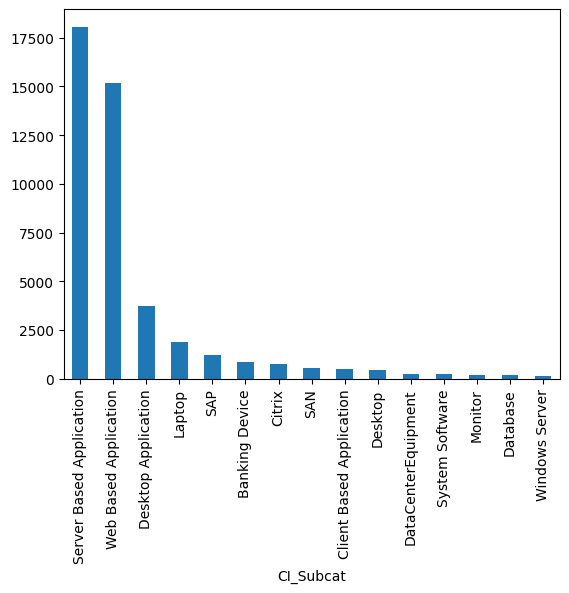

In [9]:
df['CI_Subcat'].value_counts().head(15).plot(kind='bar')

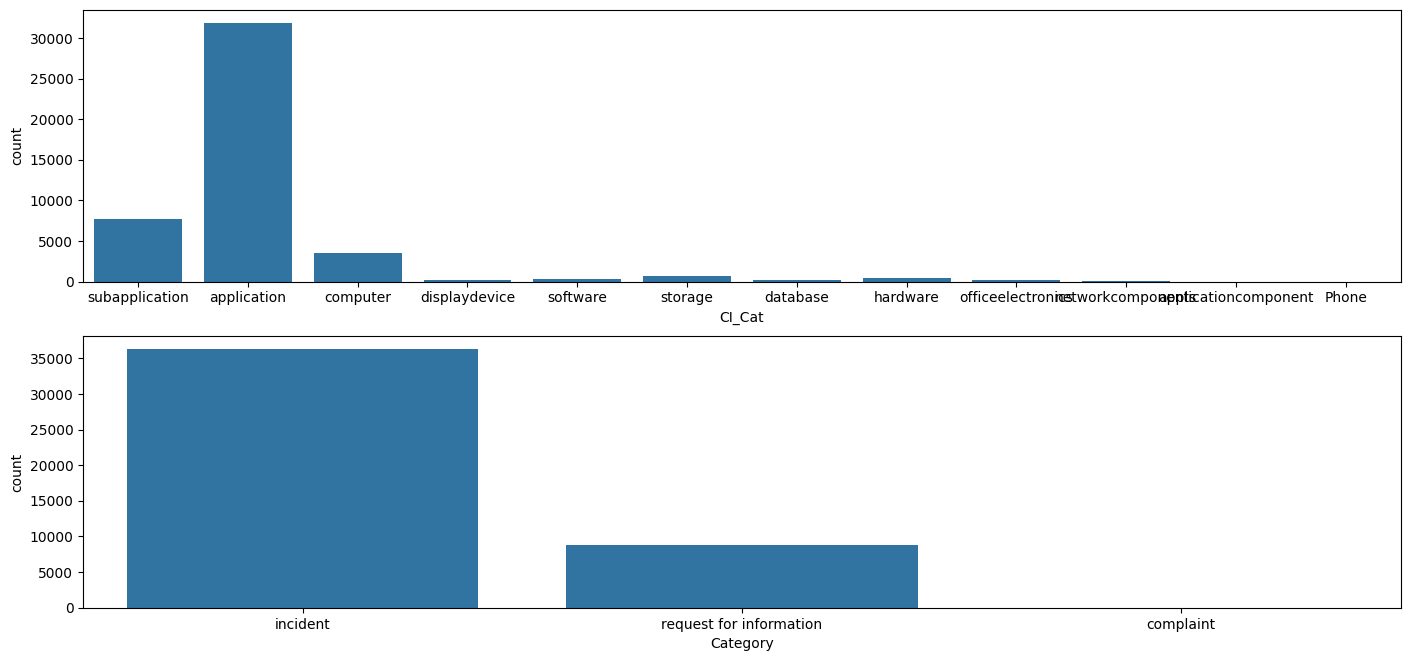

In [10]:
columns_cat_long = ['CI_Cat','Category']

plt.figure(figsize=(17,12))
for i,col in enumerate(columns_cat_long):
    plt.subplot(3,1,i+1)
    sns.countplot(x=col,data=df)

plt.show()

## Bivariate Analysis

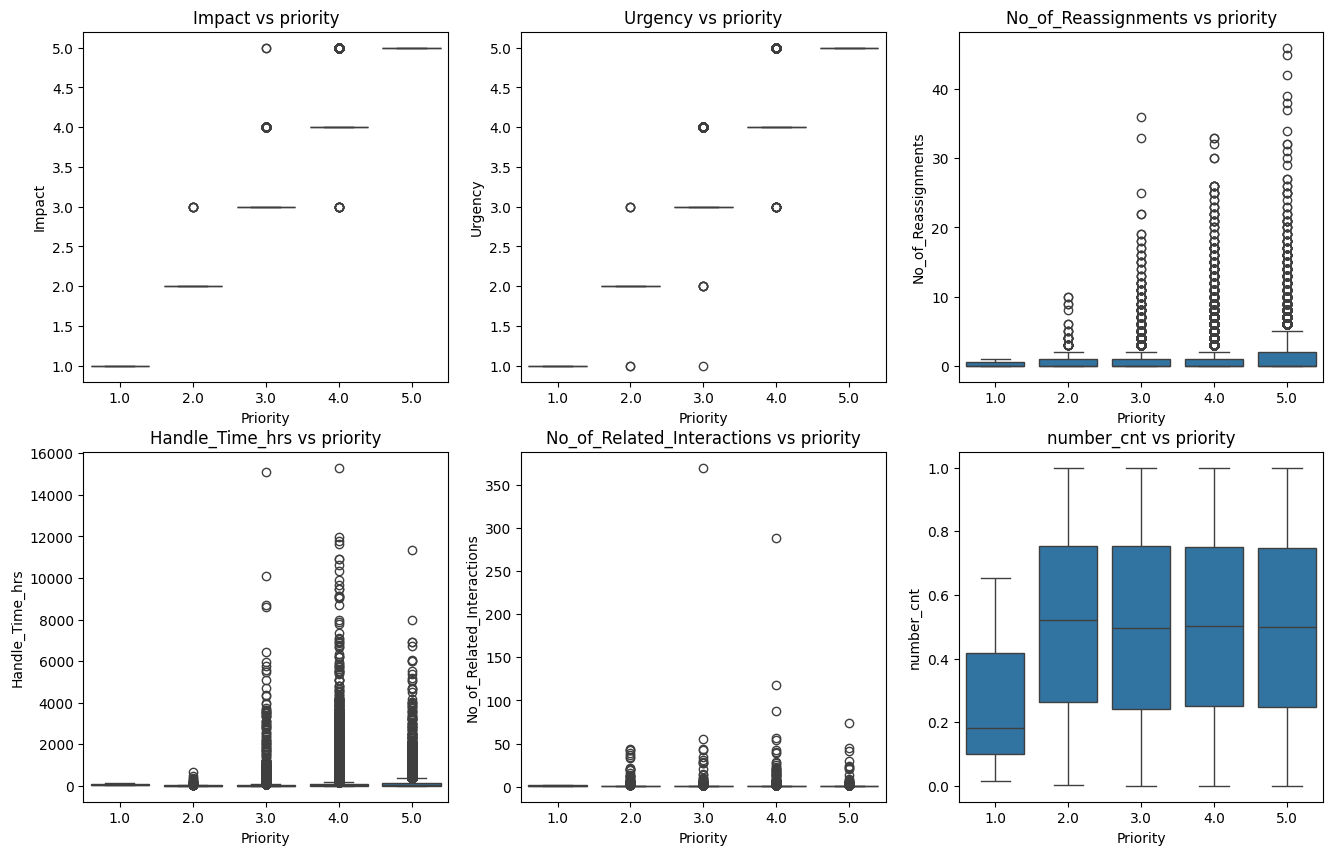

In [11]:
columns_num_BA = ['Impact', 'Urgency', 'No_of_Reassignments', 'Handle_Time_hrs', 
               'No_of_Related_Interactions', 'number_cnt']

plt.figure(figsize=(16,10))
for i,col in enumerate(columns_num_BA):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=col,x='Priority',data=df)
    plt.title(f"{col} vs priority")

plt.show()

## Priority value is convert into 0--> low priority & 1 --> high Priority

In [12]:
def check_priority(x):
    if x == 1:
        return 1
    elif x == 2:
        return 1
    else:
        return 0

df['is_high_priority'] = df['Priority'].apply(check_priority)

df['is_high_priority'].value_counts()

is_high_priority
0    44425
1      692
Name: count, dtype: int64

## Heatmap only for Numerical Columns

<Axes: >

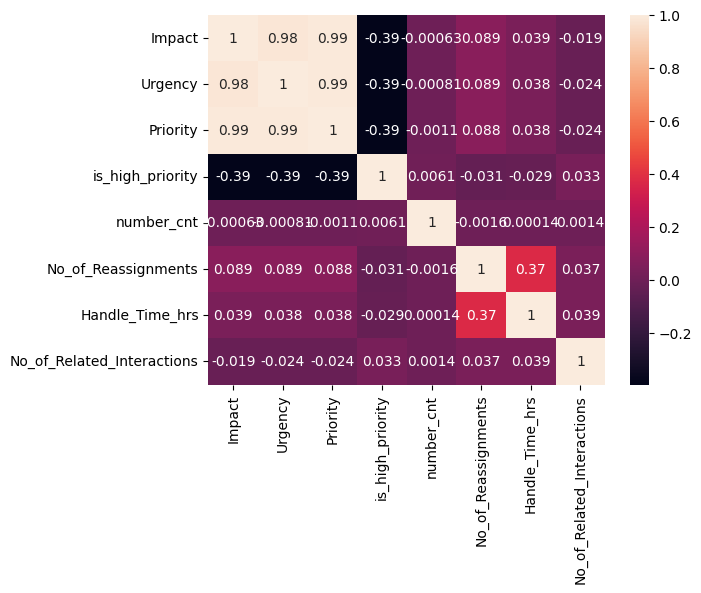

In [13]:
corr_cols = ['Impact', 'Urgency', 'Priority', 'is_high_priority', 'number_cnt', 
             'No_of_Reassignments', 'Handle_Time_hrs', 'No_of_Related_Interactions']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='rocket')

In [14]:
df['Open_Time'] = pd.to_datetime(df['Open_Time'], errors='coerce')
df['Resolved_Time'] = pd.to_datetime(df['Resolved_Time'], errors='coerce')
df['Close_Time'] = pd.to_datetime(df['Close_Time'], errors='coerce')

print(df[['Open_Time', 'Resolved_Time', 'Close_Time']].dtypes)

Open_Time        datetime64[us]
Resolved_Time    datetime64[us]
Close_Time       datetime64[us]
dtype: object


In [15]:
df['YearMonth'] = df['Open_Time'].dt.to_period('M')
monthly_trend = df.groupby('YearMonth').size()

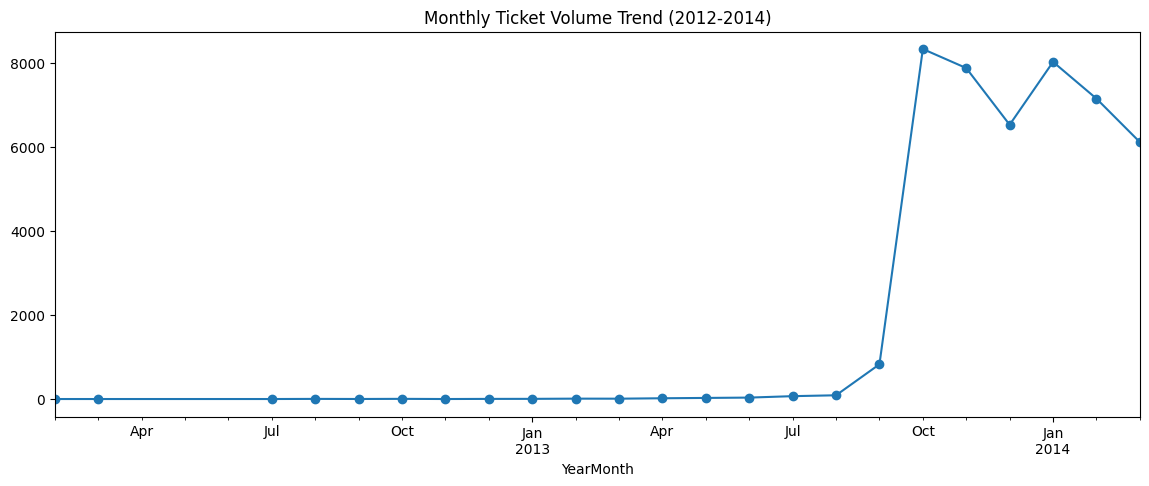

In [16]:
plt.figure(figsize=(14,5))
monthly_trend.plot(kind='line', marker='o')
plt.title('Monthly Ticket Volume Trend (2012-2014)')
plt.show()

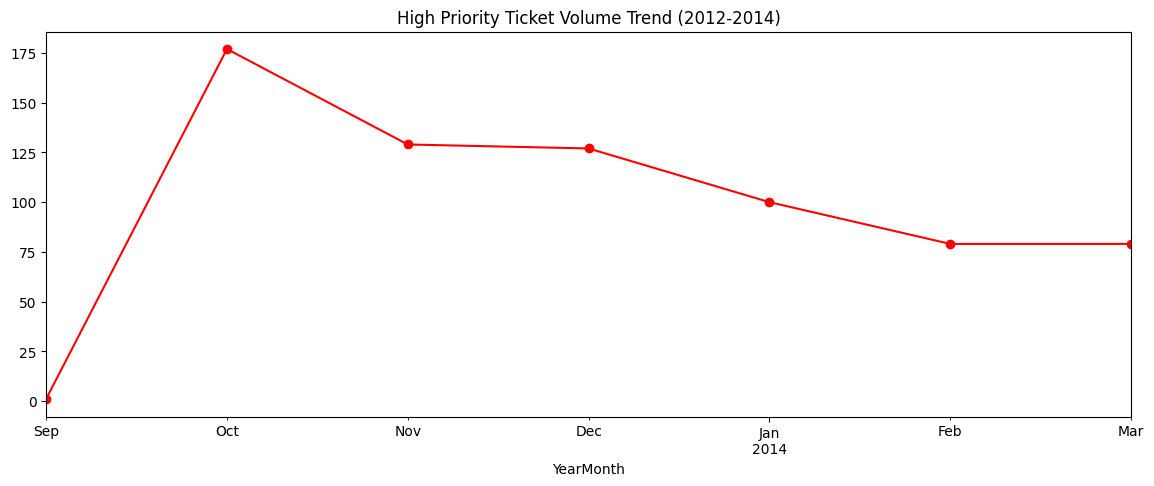

In [17]:
plt.figure(figsize=(14,5))
high_priority_trend = df[df['is_high_priority'] == 1].groupby('YearMonth').size()
high_priority_trend.plot(kind='line', marker='o', color='red')
plt.title('High Priority Ticket Volume Trend (2012-2014)')
plt.show()

## Exploratory Data Analysis (EDA) — Complete Observation Report

### Overview
Following data cleaning, a comprehensive exploratory analysis was conducted on the ITSM dataset (45,117 records) to understand distributions, relationships, and patterns before proceeding to feature engineering and modeling. The analysis covered univariate distributions, outlier detection, categorical patterns, bivariate relationships, correlation analysis, and time-based trends.

---

### 1. Univariate Analysis — Numerical Columns

Histograms with KDE were plotted for `Impact`, `Urgency`, `Priority`, `number_cnt`, `No_of_Reassignments`, `Handle_Time_hrs`, and `No_of_Related_Interactions`.

**Findings:**
- `Impact`, `Urgency`, and `Priority` show nearly identical distributions, with most tickets clustered around values **4 and 5**, and very few at **1 and 2** — indicating most incidents are lower severity.
- `number_cnt` shows a roughly uniform distribution (0–1); its business meaning remains unclear and requires further verification.
- `No_of_Reassignments`, `Handle_Time_hrs`, and `No_of_Related_Interactions` are all **strongly right-skewed**, with the majority of values low and a small number of extreme outliers pulling the tail far to the right.

---

### 2. Outlier Detection (Boxplots)

Boxplots confirmed significant outliers in the three right-skewed columns:
- `No_of_Reassignments`: most tickets reassigned 0–2 times; outliers extend to 40+.
- `Handle_Time_hrs`: most tickets resolved quickly; outliers extend beyond 14,000 hours.
- `No_of_Related_Interactions`: mostly near 0; one extreme outlier reaches 370+.

These will be addressed during feature engineering (via capping, log-transformation, or reliance on tree-based models that are robust to skew).

---

### 3. Categorical Column Distributions

High-cardinality identifier-like columns (`CI_Name`, `WBS`, `Incident_ID`, `KB_number`, `Related_Interaction`) were excluded from distribution analysis, as they behave as unique identifiers rather than meaningful categories.

| Column | Unique Values | Key Observation |
|---|---|---|
| `Status` | 2 | Dominated by **"Closed"** (~45,000+); "Work in progress" negligible |
| `Category` | 3 | **"incident"** dominates (~36,000), followed by "request for information" (~9,000); "complaint" negligible |
| `CI_Cat` | 12 | **"application"** most frequent (~32,000), followed by "subapplication" (~7,500) |
| `CI_Subcat` (top 15 shown) | 62 total | **"Server Based Application"** and **"Web Based Application"** dominate, together accounting for a large share of all tickets |

**Business Insight:** Most IT incidents originate from the application/software layer rather than hardware.

**Note:** `Alert_Status` contains only **1 unique value** across the dataset (zero variance) — a candidate for removal before modeling.

---

### 4. Bivariate Analysis — Features vs Priority

**Impact vs Priority & Urgency vs Priority:** Both show a clear, consistent monotonic relationship with `Priority`, confirming the data follows the documented Priority Matrix logic. This validated that lower numeric values represent higher severity/priority (Priority 1 = highest priority), a scale convention retained as-is since it has no effect on model performance.

**No_of_Reassignments, Handle_Time_hrs, No_of_Related_Interactions vs Priority:** All three show heavy right-skew with large outliers, concentrated mainly in Priority 3–5. Notably, **Priority 1 and 2 tickets show tighter distributions with fewer outliers**, suggesting high-priority incidents are handled more promptly and consistently — a potentially useful predictive signal.

**number_cnt vs Priority:** Priority 1 shows a distinctly narrower range (0–0.65) compared to other priority levels (0–1) — business meaning still unclear.

---

### 5. Target Variable & Class Imbalance

The target variable `is_high_priority` was defined as: `Priority ∈ {1, 2} → 1`, `Priority ∈ {3, 4, 5} → 0`.

**Class distribution:**

| Class | Count | Percentage |
|---|---|---|
| 0 (Not High Priority) | 44,425 | 98.46% |
| 1 (High Priority) | 692 | 1.53% |

This represents **severe class imbalance**, meaning accuracy alone will not be a meaningful evaluation metric. Precision, Recall, and F1-score (particularly Recall for the minority class) will be prioritized during model evaluation, and imbalance-handling techniques (`class_weight='balanced'` and/or SMOTE) will be applied during model training.

---

### 6. Correlation Analysis

A correlation heatmap was generated for numeric/ordinal columns including the target variable.

**Key findings:**
- `Impact`, `Urgency`, and `Priority` are extremely highly correlated with each other (0.98–0.99) and moderately correlated with `is_high_priority` (~-0.39). However, this relationship is a direct artifact of the Priority Matrix formula (`Priority` is derived from `Impact` and `Urgency`, and `is_high_priority` is derived from `Priority`) — including these as model features would introduce **data leakage**. All three (`Impact`, `Urgency`, `Priority`) will therefore be **excluded from the feature set**.
- `No_of_Reassignments`, `Handle_Time_hrs`, `No_of_Related_Interactions`, and `number_cnt` show very weak linear correlation with `is_high_priority` (all under 0.04). This does not necessarily indicate irrelevance — correlation only captures linear relationships, and tree-based models may still uncover non-linear patterns. Final feature relevance will be confirmed via feature importance after model training.
- `No_of_Reassignments` and `Handle_Time_hrs` show a moderate correlation with each other (0.37), worth monitoring for multicollinearity.

---

### 7. Time-Based Trend Analysis

Monthly ticket volume was plotted using `Open_Time` across 2012–2014.

**Finding:** Overall ticket volume remains near-zero from early 2012 through mid-2013, followed by a sharp increase starting **September 2013** (jumping to 8,000+ tickets/month). High-priority tickets follow an identical pattern — **all 692 High Priority tickets fall exclusively within the September 2013–March 2014 window**, peaking in October 2013 (~175 tickets) before gradually declining.

**Implication:** This strongly suggests a data collection or system adoption gap in the earlier portion of the dataset (2012–mid 2013), rather than a genuine absence of incidents during that period. This is an important limitation, as the model's understanding of "High Priority" patterns is effectively derived from a concentrated ~7-month window rather than the full 3-year span, which may affect generalization.

---

### Summary of Key Decisions Going Into Feature Engineering
- `Impact`, `Urgency`, and `Priority` will be **excluded from features** due to data leakage risk.
- `Alert_Status` will be **dropped** (zero variance).
- Identifier columns (`CI_Name`, `WBS`, `Incident_ID`, `KB_number`, `Related_Interaction`) will be **dropped**.
- Remaining categorical columns (`CI_Cat`, `CI_Subcat`, `Category`, `Status`, `Closure_Code`) will be **encoded**.
- `No_of_Reassignments`, `Handle_Time_hrs`, `No_of_Related_Interactions`, `number_cnt` will be **retained as candidate features**, subject to outlier treatment and feature importance validation.
- Class imbalance (98.46% vs 1.53%) will be addressed using `class_weight='balanced'` and/or SMOTE during model training.
- The concentrated time window of high-priority tickets (Sep 2013–Mar 2014) is noted as a data limitation affecting model generalization.

# Save the EDA file in Pickel

In [18]:
df.to_pickle('../pickle/itsm_clean.pkl')